- from [Untitled1.ipynb](/mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/RiceModel4-SFT-multi-species/Untitled1.ipynb) /mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/RiceModel4-SFT-multi-species/Untitled1.ipynb

In [1]:
import re
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d
import os

# 解析日志文件的函数保持不变
def parse_log_file(log_path):
    epochs = []
    losses = []
    lrs = []

    pattern = re.compile(
        r"📌 TRAINER LOG \|.*?"
        r"Epoch:\s*([0-9]+\.[0-9]+).*?"
        r"loss:\s*([0-9]+\.[0-9]+).*?"
        r"learning_rate:\s*([0-9]+\.[0-9]+)"
    )

    with open(log_path, 'r', encoding='utf-8') as f:
        for line in f:
            match = pattern.search(line)
            if match:
                epoch = float(match.group(1))
                loss = float(match.group(2))
                lr = float(match.group(3))
                epochs.append(epoch)
                losses.append(loss)
                lrs.append(lr)

    return np.array(epochs), np.array(losses), np.array(lrs)

# 平滑曲线的函数保持不变
def smooth_curve(y, method='moving_avg', window=10, sigma=2):
    if len(y) < 2:
        return y
    if method == 'moving_avg':
        if window >= len(y):
            window = len(y)
        cumsum = np.cumsum(np.insert(y, 0, 0))
        smoothed = (cumsum[window:] - cumsum[:-window]) / window
        pad = np.full(window - 1, np.nan)
        return np.concatenate([pad, smoothed])
    elif method == 'gaussian':
        return gaussian_filter1d(y, sigma=sigma, mode='nearest')
    else:
        return y

# 在Notebook中直接使用的函数
def plot_training_curves_in_notebook(log_path, smooth=False, method="moving_avg", window=10, sigma=2.0):
    if not os.path.isfile(log_path):
        print(f"❌ Log file not found: {log_path}")
        return

    epochs, losses, lrs = parse_log_file(log_path)

    if len(losses) == 0:
        print("❌ No training logs found.")
        return

    # 创建子图
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    # 上图：Loss
    if smooth and len(losses) > 1:
        smoothed_loss = smooth_curve(losses, method=method, window=window, sigma=sigma)
        ax1.plot(epochs, losses, color='lightgray', alpha=0.6, linewidth=1, label='Raw')
        ax1.plot(epochs, smoothed_loss, color='C0', linewidth=1.5, label=f'Smoothed ({method})')
        ax1.legend(fontsize=9)
    else:
        ax1.plot(epochs, losses, color='C0', linewidth=1.5)
    ax1.set_ylabel('Loss')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.set_title('Training Loss and Learning Rate vs Epoch')

    # 下图：Learning Rate
    ax2.plot(epochs, lrs, color='C1', linewidth=1.5)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Learning Rate')
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    output_path = os.path.splitext(log_path)[0] + "_curve.png"
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    print(f"✅ Saved combined plot to: {output_path}")
    plt.show()

✅ Saved combined plot to: /mnt/rice/default/Workspace/yangdong/gene_expression_prediction/outputs/train/202606010533/logs/training_20260601_053406_curve.png


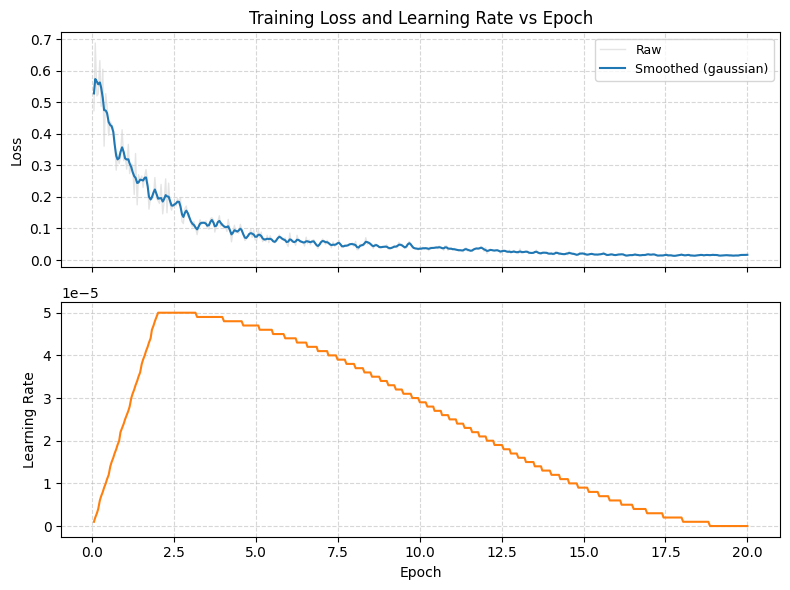

In [2]:
log_file = "/mnt/rice/default/Workspace/yangdong/gene_expression_prediction/outputs/train/202606010533/logs/training_20260601_053406.log"

plot_training_curves_in_notebook(log_file, smooth=True, method='gaussian', sigma=1.0)

In [8]:
def check_epoch_sufficiency(log_path, expected_epochs=None, min_epochs=10):
    epochs, losses, lrs = parse_log_file(log_path)
    if len(epochs) == 0:
        print("❌ 未解析到训练日志。")
        return

    max_epoch = np.max(epochs)
    unique_epoch_count = len(np.unique(epochs))

    print(f"最大 epoch: {max_epoch}")
    print(f"不同 epoch 数量: {unique_epoch_count}")

    if expected_epochs is not None:
        if max_epoch < expected_epochs:
            print(f"❌ 训练 epoch 低于预期: {max_epoch} < {expected_epochs}")
        else:
            print(f"✅ 训练 epoch 已达到预期: {max_epoch} ≥ {expected_epochs}")
    else:
        if max_epoch < min_epochs:
            print(f"❌ 训练 epoch 可能不足: {max_epoch} < {min_epochs}")
        else:
            print(f"✅ 训练 epoch 看起来足够: {max_epoch} ≥ {min_epochs}")

    return max_epoch, unique_epoch_count

check_epoch_sufficiency(log_file, min_epochs=20)

最大 epoch: 20.0
不同 epoch 数量: 438
✅ 训练 epoch 看起来足够: 20.0 ≥ 20


(20.0, 438)

In [9]:
def assess_training_curve(epochs, losses, lrs, window=20, slope_plateau=1e-4, rel_plateau=0.005):
    n = len(losses)
    if n < window + 1:
        print("样本点太少，无法评估。")
        return

    last_loss = losses[-1]
    min_loss = losses.min()
    min_epoch = epochs[np.argmin(losses)]

    recent_epochs = epochs[-window:]
    recent_losses = losses[-window:]
    slope, intercept = np.polyfit(recent_epochs, recent_losses, 1)

    prev_mean = None
    rel_change = np.nan
    if n >= 2 * window:
        prev_mean = np.mean(losses[-2*window:-window])
        rel_change = (np.mean(recent_losses) - prev_mean) / prev_mean

    lr_zero_count = np.sum(lrs[-window:] == 0.0)

    print("训练曲线评估：")
    print(f"  最后一个 epoch: {epochs[-1]:.2f}")
    print(f"  总点数: {n}")
    print(f"  训练损失最低值: {min_loss:.4f} (epoch {min_epoch:.2f})")
    print(f"  最后一个点损失: {last_loss:.4f}")
    print(f"  最近 {window} 个点损失线性拟合斜率: {slope:.6f}")
    print(f"  最近 {window} 个点平均损失: {np.mean(recent_losses):.4f}")
    if prev_mean is not None:
        print(f"  前一个窗口平均损失: {prev_mean:.4f}")
        print(f"  相对变化: {rel_change:.4f}")
    print(f"  最近 {window} 个点中 lr 为 0 的点: {lr_zero_count}/{window}")

    plateau = abs(slope) < slope_plateau and (np.isnan(rel_change) or abs(rel_change) < rel_plateau)

    if plateau:
        print("\n判断：")
        print("  - 训练损失已经趋于平稳，模型在当前训练设置下基本收敛。")
        if lr_zero_count / window > 0.5:
            print("  - 注意：后期学习率已经降到 0，继续增加 epoch 可能不会带来实际参数更新。")
        print("  - 是否增加 epoch 需要看验证集表现；单从训练损失无法判断是否过拟合。")
    else:
        print("\n判断：")
        print("  - 训练损失仍有下降趋势，继续增加 epoch 可能有收益。")
        if lr_zero_count / window > 0.5:
            print("  - 但当前后期 lr 已经降到 0，若要继续提升，应调整学习率调度而不是简单增加 epoch。")

    if min_loss < 0.02:
        print("  - 当前训练损失已经很低，若验证集也表现良好，通常不需要大幅增加 epoch。")
    else:
        print("  - 当前训练损失仍有改进空间，可结合验证集判断是否继续训练。")

assess_training_curve(epochs, losses, lrs, window=20)

训练曲线评估：
  最后一个 epoch: 20.00
  总点数: 438
  训练损失最低值: 0.0117 (epoch 17.58)
  最后一个点损失: 0.0168
  最近 20 个点损失线性拟合斜率: 0.002591
  最近 20 个点平均损失: 0.0149
  前一个窗口平均损失: 0.0155
  相对变化: -0.0356
  最近 20 个点中 lr 为 0 的点: 20/20

判断：
  - 训练损失仍有下降趋势，继续增加 epoch 可能有收益。
  - 但当前后期 lr 已经降到 0，若要继续提升，应调整学习率调度而不是简单增加 epoch。
  - 当前训练损失已经很低，若验证集也表现良好，通常不需要大幅增加 epoch。
